# 02 — Exploratory Data Analysis (EDA)

In this notebook, we will do Exploratory Data Analysis 

We will:
- Load the cleaned datasets (Movies + TV Shows)
- Perform quick dataset profiling (shape, columns, missingness, duplicates)
- Use descriptive statistics to summarize distributions
- Build exploratory charts using **matplotlib** (bar charts, histograms, line charts)

**Datasets**
- `MoviesOnStreamingPlatforms_Cleaned.csv`
- `TVShowsOnStreamingPlatforms_Cleaned.csv`


## 0. Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

DATA_DIR = Path("G:\The US\Gradute School\Build Project\Streaming wars\streaming-bi-template\streaming-bi-template\Data")  # adjust if needed

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

<>:9: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:9: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
C:\Users\gideo\AppData\Local\Temp\ipykernel_32064\3321284601.py:9: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  DATA_DIR = Path("G:\The US\Gradute School\Build Project\Streaming wars\streaming-bi-template\streaming-bi-template\Data")  # adjust if needed


## 1. Load the cleaned datasets

In [25]:
movies = pd.read_csv(MOVIES_PATH)
tv     = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:    ", tv.shape)

movies.head()

Movies shape: (9515, 19)
TV shape:     (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7,0,david attenborough: a life on our planet
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,94.0,7,0,lagaan: once upon a time in india
4,5,Roma,2018,18+,94/100,1,0,0,0,movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,94.0,18,0,roma


In [26]:
tv.head()

,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,Breaking Bad,2008,18+,100/100,1,0,0,0,tv_show,"crime television series, drama television seri...",United States,"American English, Spanish language in the Amer...",10.0,tt0903747,100,18,1,breaking bad
1,2,Stranger Things,2016,16+,96/100,1,0,0,0,tv_show,"science fiction television program, horror tel...",United States,English,9.0,tt4574334,96,16,1,stranger things
2,3,Attack on Titan,2013,18+,95/100,1,1,0,0,tv_show,reality television,United States,English,9.0/10,tt0092400,95,18,1,attack on titan
3,4,Better Call Saul,2015,18+,94/100,1,0,0,0,tv_show,"legal drama, crime television series",United States,English,10.0,tt3032476,94,18,1,better call saul
4,5,Dark,2017,16+,93/100,1,0,0,0,tv_show,"science fiction television program, drama tele...",Germany,German,10.0,tt5753856,93,16,1,dark


## 2. Quick dataset overview

In [27]:
def quick_overview(df: pd.DataFrame, name: str):
    print(f"=== {name} ===")
    display(df.head(3))
    print("\nColumns & dtypes:")
    display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)}))
    print("\nMissing values (top 20):")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing.head(20).to_frame("missing_count"))
    print("\nInfo:")
    df.info()

quick_overview(movies, "Movies")

=== Movies ===


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7,0,david attenborough: a life on our planet



Columns & dtypes:


,column,dtype
ID,ID,int64
Title,Title,str
Year,Year,int64
Age,Age,str
Rotten Tomatoes,Rotten Tomatoes,str
Netflix,Netflix,int64
Hulu,Hulu,int64
Prime Video,Prime Video,int64
Disney+,Disney+,int64
Type,Type,str



Missing values (top 20):


,missing_count
ID,0
Title,0
Year,0
Age,0
Rotten Tomatoes,0
Netflix,0
Hulu,0
Prime Video,0
Disney+,0
Type,0



Info:
<class 'pandas.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    9515 non-null   int64  
 1   Title                 9515 non-null   str    
 2   Year                  9515 non-null   int64  
 3   Age                   9515 non-null   str    
 4   Rotten Tomatoes       9515 non-null   str    
 5   Netflix               9515 non-null   int64  
 6   Hulu                  9515 non-null   int64  
 7   Prime Video           9515 non-null   int64  
 8   Disney+               9515 non-null   int64  
 9   Type                  9515 non-null   str    
 10  Genre                 9515 non-null   str    
 11  Country               9515 non-null   str    
 12  Language              9515 non-null   str    
 13  IMDb                  9515 non-null   float64
 14  IMDb_ID               9515 non-null   str    
 15  RottenTomatoes_Score  951

In [28]:
quick_overview(tv, "TV Shows")

=== TV Shows ===


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,Breaking Bad,2008,18+,100/100,1,0,0,0,tv_show,"crime television series, drama television seri...",United States,"American English, Spanish language in the Amer...",10.0,tt0903747,100,18,1,breaking bad
1,2,Stranger Things,2016,16+,96/100,1,0,0,0,tv_show,"science fiction television program, horror tel...",United States,English,9.0,tt4574334,96,16,1,stranger things
2,3,Attack on Titan,2013,18+,95/100,1,1,0,0,tv_show,reality television,United States,English,9.0/10,tt0092400,95,18,1,attack on titan



Columns & dtypes:


,column,dtype
ID,ID,int64
Title,Title,str
Year,Year,int64
Age,Age,str
Rotten Tomatoes,Rotten Tomatoes,str
Netflix,Netflix,int64
Hulu,Hulu,int64
Prime Video,Prime Video,int64
Disney+,Disney+,int64
Type,Type,str



Missing values (top 20):


,missing_count
ID,0
Title,0
Year,0
Age,0
Rotten Tomatoes,0
Netflix,0
Hulu,0
Prime Video,0
Disney+,0
Type,0



Info:
<class 'pandas.DataFrame'>
RangeIndex: 5368 entries, 0 to 5367
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    5368 non-null   int64
 1   Title                 5368 non-null   str  
 2   Year                  5368 non-null   int64
 3   Age                   5368 non-null   str  
 4   Rotten Tomatoes       5368 non-null   str  
 5   Netflix               5368 non-null   int64
 6   Hulu                  5368 non-null   int64
 7   Prime Video           5368 non-null   int64
 8   Disney+               5368 non-null   int64
 9   Type                  5368 non-null   str  
 10  Genre                 5368 non-null   str  
 11  Country               5368 non-null   str  
 12  Language              5368 non-null   str  
 13  IMDb                  5368 non-null   str  
 14  IMDb_ID               5368 non-null   str  
 15  RottenTomatoes_Score  5368 non-null   int64
 16  Age_Min   

## 3. Data quality checks

In [29]:
def data_quality_checks(df: pd.DataFrame, name: str, subset_for_dupes=None):
    print(f"=== {name} quality checks ===")

    # Duplicates
    if subset_for_dupes is None:
        dup_count = df.duplicated().sum()
        print("Exact duplicate rows:", int(dup_count))
    else:
        dup_count = df.duplicated(subset=subset_for_dupes).sum()
        print(f"Duplicates based on {subset_for_dupes}:", int(dup_count))

    # Show sample duplicates if any
    if dup_count > 0:
        if subset_for_dupes is None:
            dup_rows = df[df.duplicated(keep=False)].head(10)
        else:
            dup_rows = df[df.duplicated(subset=subset_for_dupes, keep=False)].sort_values(subset_for_dupes).head(10)
        display(dup_rows)

    # Numeric summary
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    print("\nNumeric columns:", numeric_cols[:20], "..." if len(numeric_cols) > 20 else "")
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))

    print("\nDone.\n")

subset_movies = [c for c in ['Title', 'Year'] if c and c in movies.columns]
subset_tv     = [c for c in ['Title', 'Year'] if c and c in tv.columns]

data_quality_checks(movies, "Movies", subset_for_dupes=subset_movies if subset_movies else None)
data_quality_checks(tv, "TV Shows", subset_for_dupes=subset_tv if subset_tv else None)

=== Movies quality checks ===
Duplicates based on ['Title', 'Year']: 0

Numeric columns: ['ID', 'Year', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'IMDb', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw'] 


,count,mean,std,min,25%,50%,75%,max
ID,9515.0,4758.000000,2746.888239,1.0,2379.5,4758.0,7136.5,9515.0
Year,9515.0,2007.422386,19.130367,1914.0,2006.0,2015.0,2018.0,2021.0
Netflix,9515.0,0.388334,0.487397,0.0,0.0,0.0,1.0,1.0
Hulu,9515.0,0.110037,0.312952,0.0,0.0,0.0,0.0,1.0
Prime Video,9515.0,0.432265,0.495417,0.0,0.0,0.0,1.0,1.0
Disney+,9515.0,0.096900,0.295837,0.0,0.0,0.0,0.0,1.0
IMDb,9515.0,6.720494,1.815770,1.0,6.0,7.0,7.3,10.0
RottenTomatoes_Score,9515.0,53.543878,13.192884,10.0,44.0,52.0,62.0,98.0
Age_Min,9515.0,15.132738,3.229361,7.0,16.0,16.0,16.0,18.0
Type_raw,9515.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0



Done.

=== TV Shows quality checks ===
Duplicates based on ['Title', 'Year']: 0

Numeric columns: ['ID', 'Year', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw'] 


,count,mean,std,min,25%,50%,75%,max
ID,5368.0,2814.945790,1672.385727,1.0,1345.75,2788.0,4308.25,5717.0
Year,5368.0,2012.628726,10.142813,1904.0,2011.00,2016.0,2018.00,2021.0
Netflix,5368.0,0.367176,0.482080,0.0,0.00,0.0,1.00,1.0
Hulu,5368.0,0.301975,0.459157,0.0,0.00,0.0,1.00,1.0
Prime Video,5368.0,0.341095,0.474122,0.0,0.00,0.0,1.00,1.0
Disney+,5368.0,0.065387,0.247231,0.0,0.00,0.0,0.00,1.0
RottenTomatoes_Score,5368.0,47.220380,19.555753,10.0,36.00,48.0,60.00,100.0
Age_Min,5368.0,14.919896,3.467906,7.0,16.00,16.0,16.00,18.0
Type_raw,5368.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0



Done.



## 4. Descriptive statistics (numbers that summarize patterns)


Descriptive stats help you understand:
- **Typical values** (mean/median)
- **Spread** (std, IQR)
- **Extremes** (min/max)
- **Frequency** (value_counts for categories)


In [30]:
display(movies.describe(include=[np.number]).T.head(30))

,count,mean,std,min,25%,50%,75%,max
ID,9515.0,4758.000000,2746.888239,1.0,2379.5,4758.0,7136.5,9515.0
Year,9515.0,2007.422386,19.130367,1914.0,2006.0,2015.0,2018.0,2021.0
Netflix,9515.0,0.388334,0.487397,0.0,0.0,0.0,1.0,1.0
Hulu,9515.0,0.110037,0.312952,0.0,0.0,0.0,0.0,1.0
Prime Video,9515.0,0.432265,0.495417,0.0,0.0,0.0,1.0,1.0
Disney+,9515.0,0.096900,0.295837,0.0,0.0,0.0,0.0,1.0
IMDb,9515.0,6.720494,1.815770,1.0,6.0,7.0,7.3,10.0
RottenTomatoes_Score,9515.0,53.543878,13.192884,10.0,44.0,52.0,62.0,98.0
Age_Min,9515.0,15.132738,3.229361,7.0,16.0,16.0,16.0,18.0
Type_raw,9515.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [31]:
# Categorical summary
display(tv.describe(include=["object"]).T.head(30))

C:\Users\gideo\AppData\Local\Temp\ipykernel_32064\1038898995.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(tv.describe(include=["object"]).T.head(30))


,count,unique,top,freq
Title,5368,5368,Breaking Bad,1
Age,5368,5,16+,3122
Rotten Tomatoes,5368,85,10/100,304
Type,5368,1,tv_show,5368
Genre,5368,874,reality television,3348
Country,5368,115,United States,4123
Language,5368,98,English,4790
IMDb,5368,133,10.0,1414
IMDb_ID,5368,2677,tt0092400,2682
Title_key,5368,5368,breaking bad,1


## 5. Live coding demo — Movies (bar, histogram, line chart)

In [32]:
MOVIES_YEAR_COL   = 'Year'
MOVIES_GENRE_COL  = 'Genre'
MOVIES_RATING_COL = 'IMDb'
MOVIES_PLATFORM_COLS = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

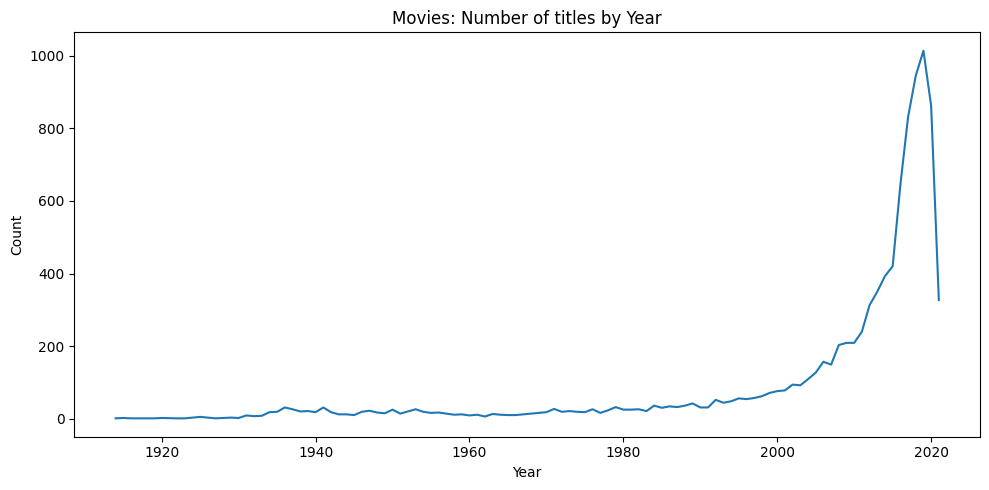

In [33]:
# 1) Line chart: content by year
def line_counts_by_year(df: pd.DataFrame, year_col: str, title: str):
    s = pd.to_numeric(df[year_col], errors="coerce").dropna().astype(int)
    counts = s.value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    plt.plot(counts.index, counts.values)
    plt.title(title)
    plt.xlabel(year_col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

line_counts_by_year(movies, MOVIES_YEAR_COL, f"Movies: Number of titles by {MOVIES_YEAR_COL}")

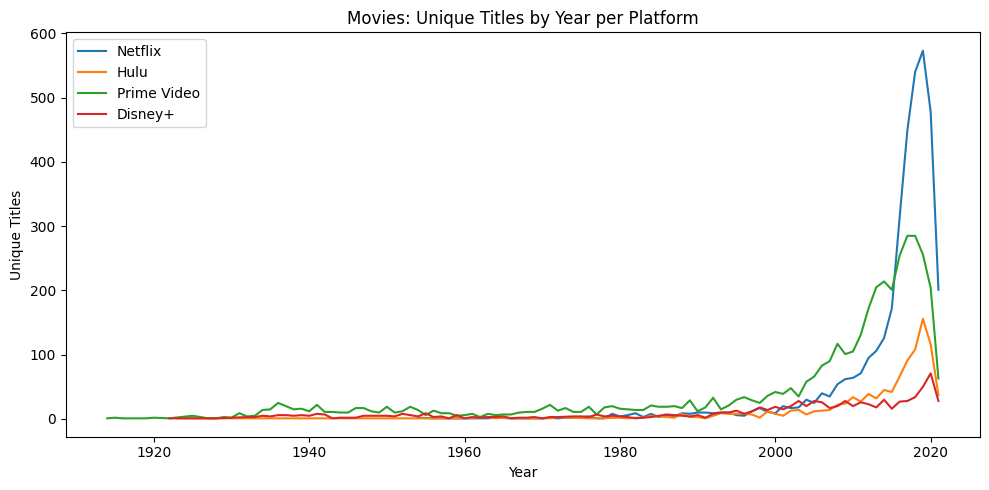

In [34]:
# 2) Line chart (multiple lines): content by year
def line_counts_by_year_multi(
    df: pd.DataFrame,
    year_col: str,
    platform_cols: list,
    title: str,
    count_col: str | None = None,
    min_year: int = 1900,
    max_year: int | None = None
):
    """
    Plot multiple lines by platform.

    Parameters
    ----------
    df : DataFrame
    year_col : str
    platform_cols : list of platform indicator columns (e.g. ['Netflix','Hulu',...])
    title : str
    count_col : str | None
        If None -> count rows
        If provided -> count unique values of this column
    """

    d = df.copy()

    # Clean year
    d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    d = d.dropna(subset=[year_col])
    d[year_col] = d[year_col].astype(int)

    if max_year is None:
        max_year = pd.Timestamp.now().year

    d = d[(d[year_col] >= min_year) & (d[year_col] <= max_year)]

    plt.figure(figsize=(10, 5))

    for platform in platform_cols:
        if platform not in d.columns:
            continue

        subset = d[d[platform] == 1]

        if count_col is None:
            counts = subset.groupby(year_col).size()
        else:
            counts = (
                subset
                .dropna(subset=[count_col])
                .groupby(year_col)[count_col]
                .nunique()
            )

        counts = counts.sort_index()

        plt.plot(counts.index, counts.values, label=platform)

    plt.title(title)
    plt.xlabel(year_col)
    plt.ylabel("Unique Titles" if count_col else "Count (rows)")
    plt.legend()
    plt.tight_layout()
    plt.show()

line_counts_by_year_multi(
    movies,
    year_col="Year",
    platform_cols=["Netflix", "Hulu", "Prime Video", "Disney+"],
    title="Movies: Unique Titles by Year per Platform",
    count_col="Title"   # important to avoid duplicates
)

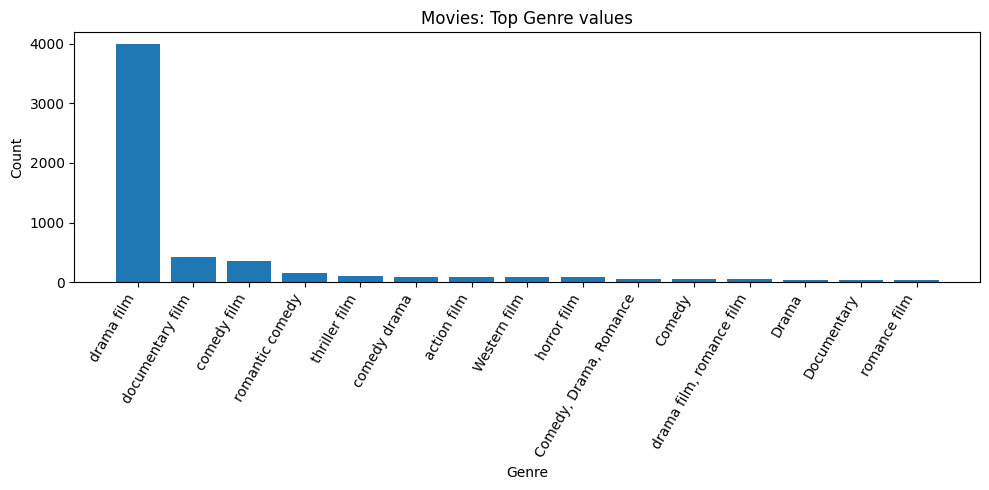

In [35]:
# 3) Bar chart: genre distribution (top 15)
def top_bar(series: pd.Series, title: str, xlabel: str = "", ylabel: str = "Count", top_n: int = 15, rotate: int = 45):
    vc = series.dropna().value_counts().head(top_n)
    plt.figure(figsize=(10, 5))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.show()

top_bar(movies[MOVIES_GENRE_COL], f"Movies: Top {MOVIES_GENRE_COL} values", xlabel=MOVIES_GENRE_COL, top_n=15, rotate=60)

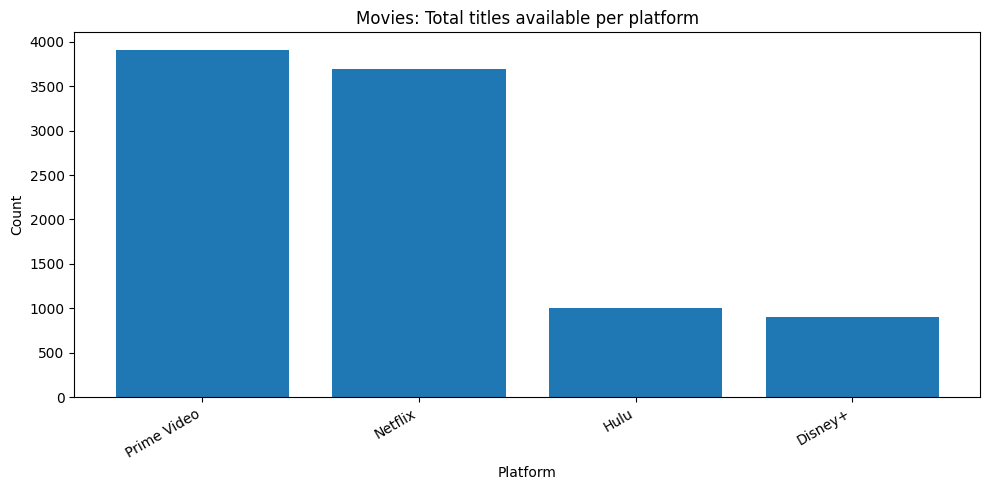

In [36]:
# 4) Bar chart: platform totals
# Create readable platform label
movies["Platform_Label"] = np.select(
    [
        movies["Netflix"] == 1,
        movies["Hulu"] == 1,
        movies["Prime Video"] == 1,
        movies["Disney+"] == 1
    ],
    ["Netflix", "Hulu", "Prime Video", "Disney+"],
    default="Other"
)
top_bar(movies["Platform_Label"], "Movies: Total titles available per platform", xlabel="Platform", rotate=30)

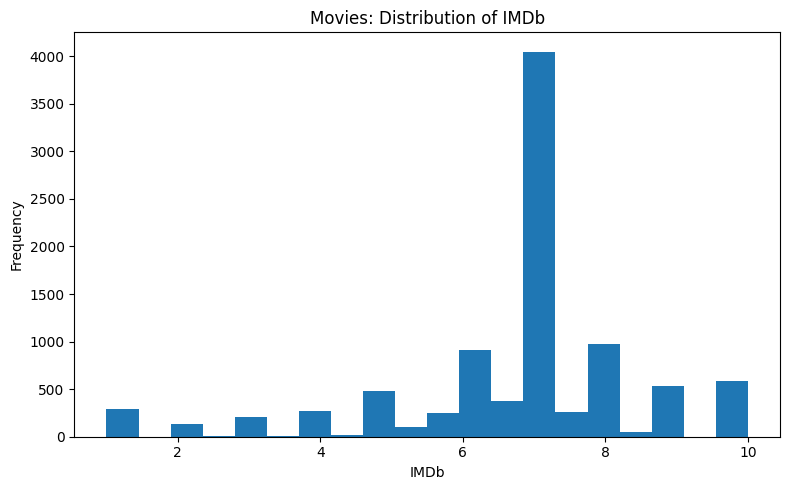

In [37]:
# 5) Histogram: ratings distribution
def hist(series: pd.Series, title: str, bins: int = 20, xlabel: str = "", ylabel: str = "Frequency"):
    s = pd.to_numeric(series, errors="coerce").dropna()
    plt.figure(figsize=(8, 5))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

hist(movies[MOVIES_RATING_COL], f"Movies: Distribution of {MOVIES_RATING_COL}", bins=20, xlabel=MOVIES_RATING_COL)

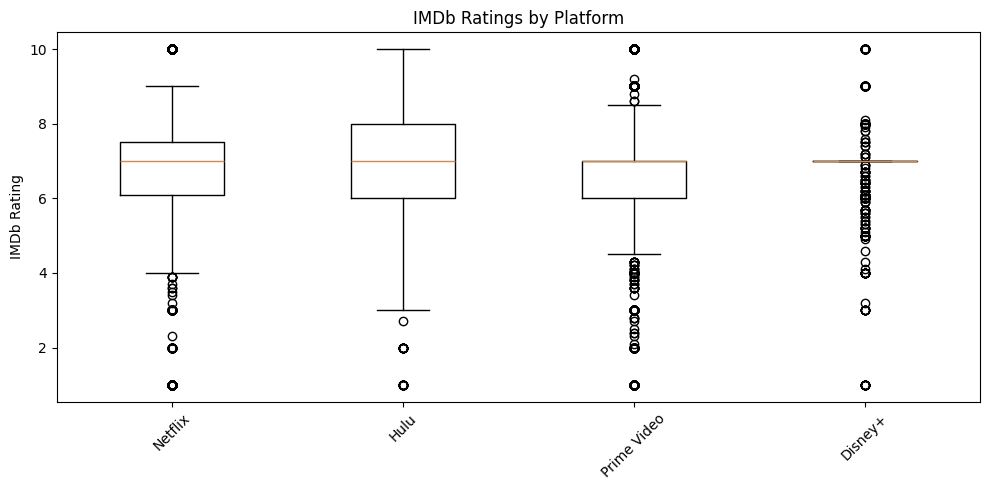

In [38]:
# 6) Box chart: ratings by platform
def box_plot(df: pd.DataFrame, column: str, by: str | None = None, 
             title: str = "", ylabel: str = "", rotate: int = 45):
    df_clean = df.copy()
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

    if by is None:
        plt.figure(figsize=(6, 5))
        plt.boxplot(df_clean[column].dropna())
        plt.title(title if title else f"Boxplot of {column}")
        plt.ylabel(ylabel if ylabel else column)
    else:
        grouped_data = [
            df_clean[df_clean[by] == cat][column].dropna()
            for cat in df_clean[by].dropna().unique()
        ]

        categories = df_clean[by].dropna().unique()

        plt.figure(figsize=(10, 5))
        plt.boxplot(grouped_data)
        plt.xticks(range(1, len(categories) + 1), categories, rotation=rotate)
        plt.title(title if title else f"{column} by {by}")
        plt.ylabel(ylabel if ylabel else column)

    plt.tight_layout()
    plt.show()
    
box_plot(
    movies,
    column="IMDb",
    by="Platform_Label",
    title="IMDb Ratings by Platform",
    ylabel="IMDb Rating"
)

In [39]:
movies[movies["Disney+"]==1]["IMDb"].describe()

count    922.000000
mean       6.920824
std        1.347270
min        1.000000
25%        7.000000
50%        7.000000
75%        7.000000
max       10.000000
Name: IMDb, dtype: float64

## 6. Live coding demo — TV Shows (bar, histogram, line chart)

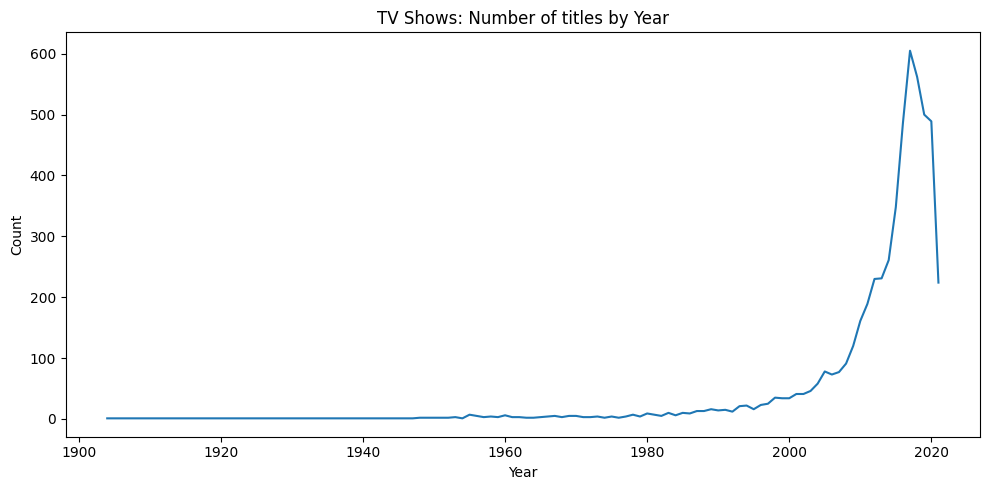

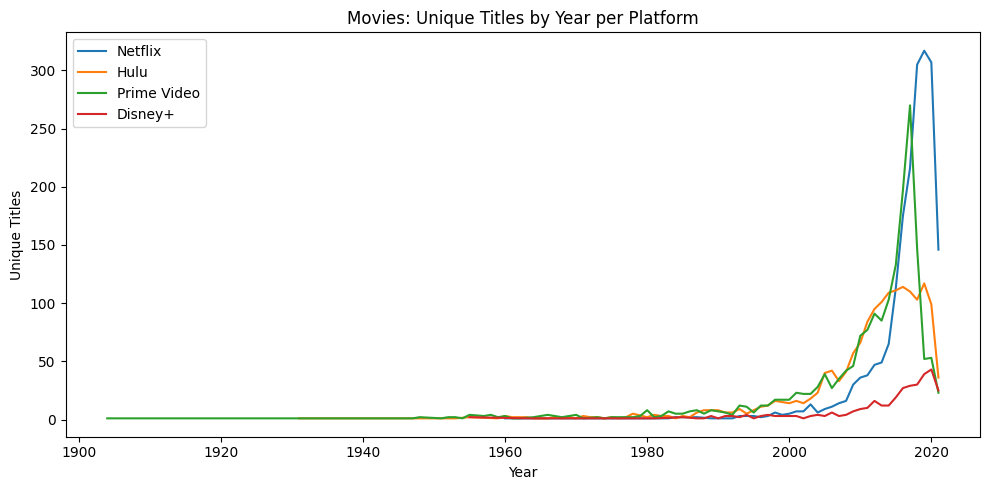

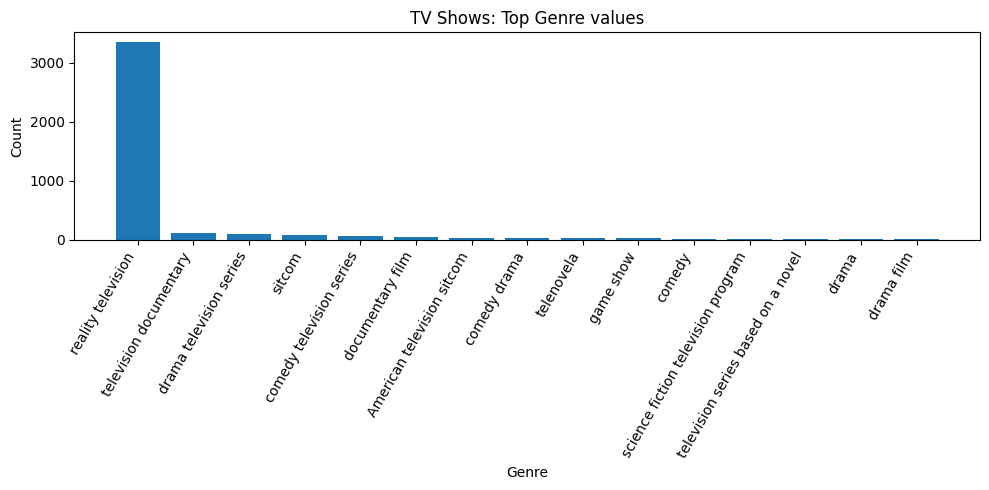

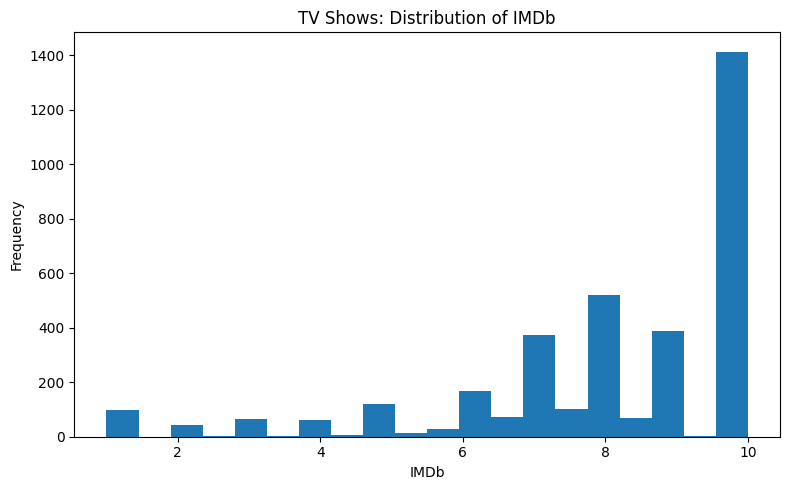

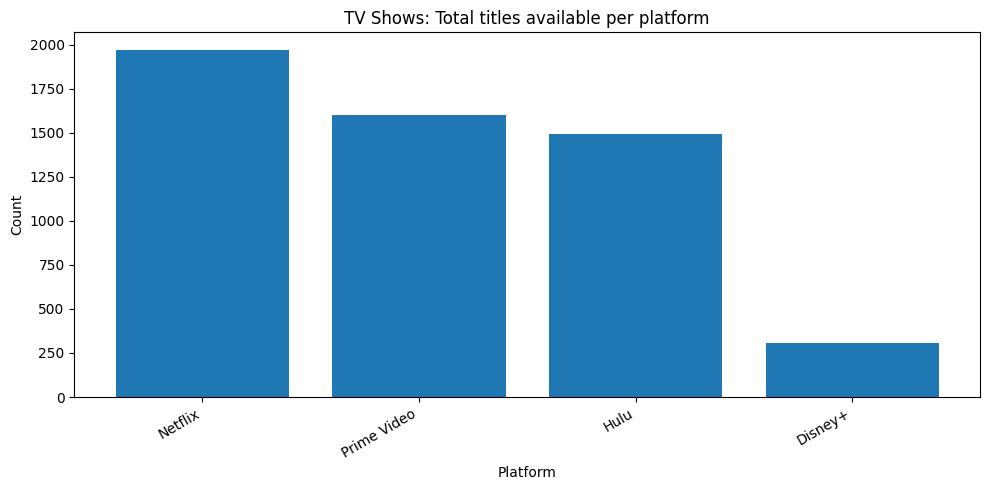

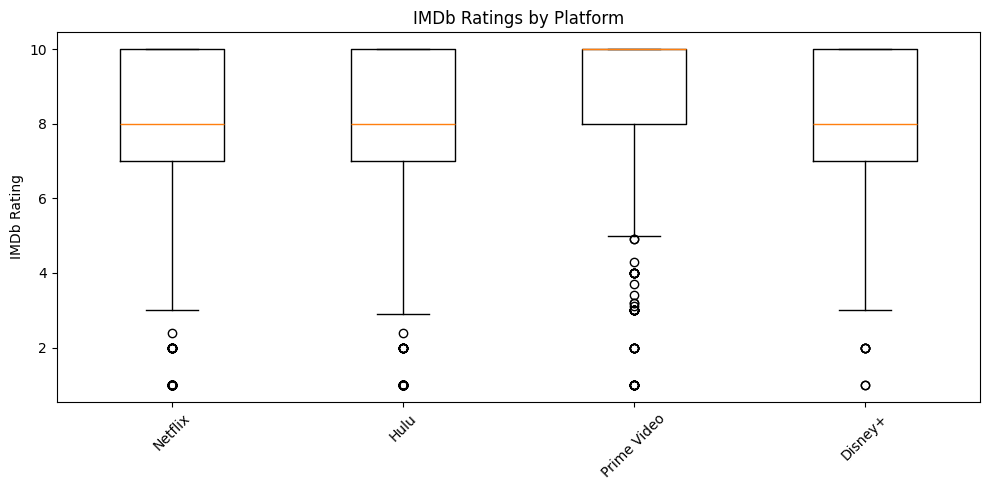

In [40]:
TV_YEAR_COL   = 'Year'
TV_GENRE_COL  = 'Genre'
TV_RATING_COL = 'IMDb'
TV_PLATFORM_COLS = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

# 1) Line chart: content by year
line_counts_by_year(tv, TV_YEAR_COL, f"TV Shows: Number of titles by {TV_YEAR_COL}")

# 2) Line chart (multiple lines): content by year
line_counts_by_year_multi(
    tv,
    year_col="Year",
    platform_cols=["Netflix", "Hulu", "Prime Video", "Disney+"],
    title="Movies: Unique Titles by Year per Platform",
    count_col="Title"   # important to avoid duplicates
)

# 3) Bar chart: genre distribution (top 15)
top_bar(tv[TV_GENRE_COL], f"TV Shows: Top {TV_GENRE_COL} values", xlabel=TV_GENRE_COL, top_n=15, rotate=60)

# 4) Histogram: ratings distribution
hist(tv[TV_RATING_COL], f"TV Shows: Distribution of {TV_RATING_COL}", bins=20, xlabel=TV_RATING_COL)

# 5) Bar chart: platform totals
# Create readable platform label
tv["Platform_Label"] = np.select(
    [
        tv["Netflix"] == 1,
        tv["Hulu"] == 1,
        tv["Prime Video"] == 1,
        tv["Disney+"] == 1
    ],
    ["Netflix", "Hulu", "Prime Video", "Disney+"],
    default="Other"
)
top_bar(tv["Platform_Label"], "TV Shows: Total titles available per platform", xlabel="Platform", rotate=30)

# 6) Box chart: ratings by platform
box_plot(
    tv,
    column="IMDb",
    by="Platform_Label",
    title="IMDb Ratings by Platform",
    ylabel="IMDb Rating"
)

In [41]:

df = tv 

df.columns

Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre',
       'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key',
       'Platform_Label'],
      dtype='str')

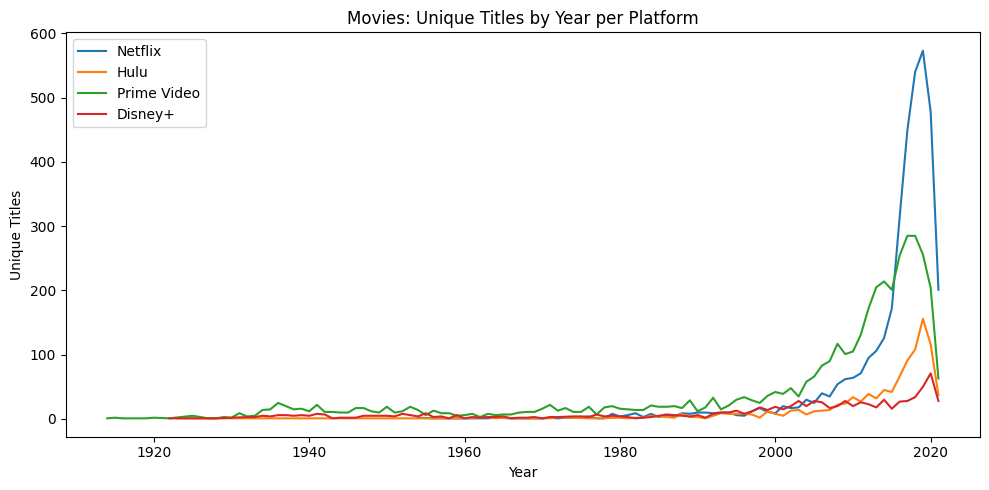

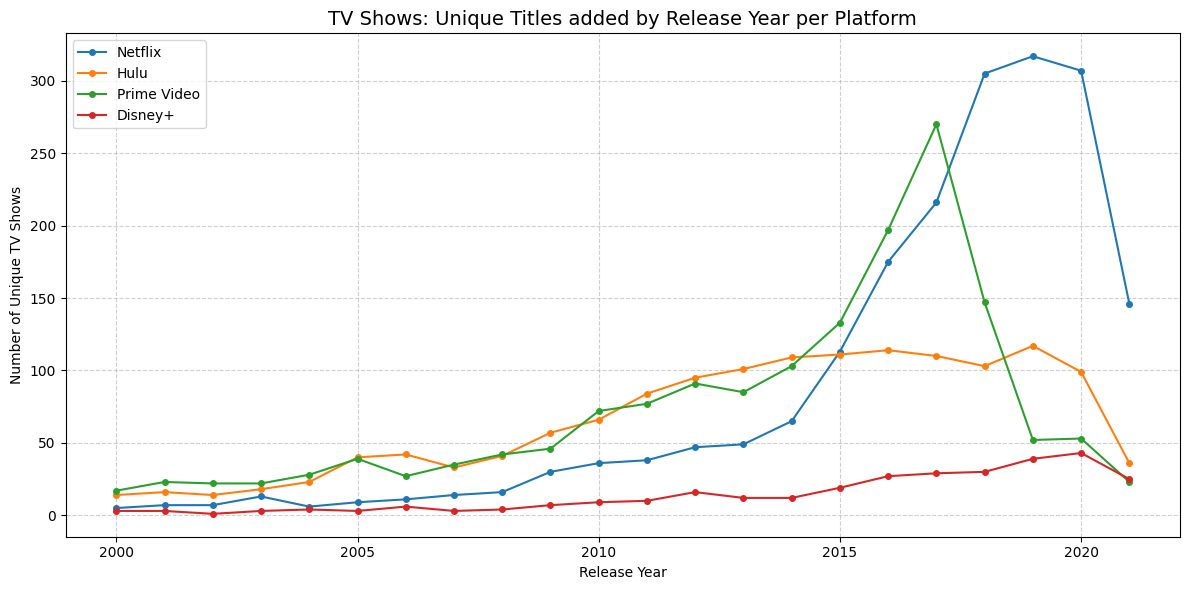

In [42]:
# 2) Line chart (multiple lines): content by year
def line_counts_by_year_multi(
    df: pd.DataFrame,
    year_col: str,
    platform_cols: list,
    title: str,
    count_col: str | None = None,
    min_year: int = 1900,
    max_year: int | None = None
):
    """
    Plot multiple lines by platform.

    Parameters
    ----------
    df : DataFrame
    year_col : str
    platform_cols : list of platform indicator columns (e.g. ['Netflix','Hulu',...])
    title : str
    count_col : str | None
        If None -> count rows
        If provided -> count unique values of this column
    """

    d = df.copy()

    # Clean year
    d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    d = d.dropna(subset=[year_col])
    d[year_col] = d[year_col].astype(int)

    if max_year is None:
        max_year = pd.Timestamp.now().year

    d = d[(d[year_col] >= min_year) & (d[year_col] <= max_year)]

    plt.figure(figsize=(10, 5))

    for platform in platform_cols:
        if platform not in d.columns:
            continue

        subset = d[d[platform] == 1]

        if count_col is None:
            counts = subset.groupby(year_col).size()
        else:
            counts = (
                subset
                .dropna(subset=[count_col])
                .groupby(year_col)[count_col]
                .nunique()
            )

        counts = counts.sort_index()

        plt.plot(counts.index, counts.values, label=platform)

    plt.title(title)
    plt.xlabel(year_col)
    plt.ylabel("Unique Titles" if count_col else "Count (rows)")
    plt.legend()
    plt.tight_layout()
    plt.show()

line_counts_by_year_multi(
    movies,
    year_col="Year",
    platform_cols=["Netflix", "Hulu", "Prime Video", "Disney+"],
    title="Movies: Unique Titles by Year per Platform",
    count_col="Title"   # important to avoid duplicates
)



def line_counts_by_year_multi(
    df: pd.DataFrame,
    year_col: str,
    platform_cols: list,
    title: str,
    count_col: str | None = None,
    min_year: int = 1900,
    max_year: int | None = None
):
    d = df.copy()
    d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    d = d.dropna(subset=[year_col])
    d[year_col] = d[year_col].astype(int)
    if max_year is None:
        max_year = pd.Timestamp.now().year
    d = d[(d[year_col] >= min_year) & (d[year_col] <= max_year)]
    plt.figure(figsize=(12, 6))
    for platform in platform_cols:
        if platform not in d.columns:
            print(f"Warning: {platform} not found in dataset.")
            continue
        subset = d[d[platform] == 1]
        if count_col is None:
            counts = subset.groupby(year_col).size()
        else:
            counts = (
                subset
                .dropna(subset=[count_col])
                .groupby(year_col)[count_col]
                .nunique()
            )
        counts = counts.sort_index()
        plt.plot(counts.index, counts.values, marker='o', markersize=4, label=platform)
    plt.title(title, fontsize=14)
    plt.xlabel("Release Year")
    plt.ylabel("Number of Unique TV Shows" if count_col else "Count")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
line_counts_by_year_multi(
    df=tv, 
    year_col="Year",
    platform_cols=["Netflix", "Hulu", "Prime Video", "Disney+"],
    title="TV Shows: Unique Titles added by Release Year per Platform",
    count_col="Title",
    min_year=2000 
)

Total rows in your 'movies' variable right now: 9515


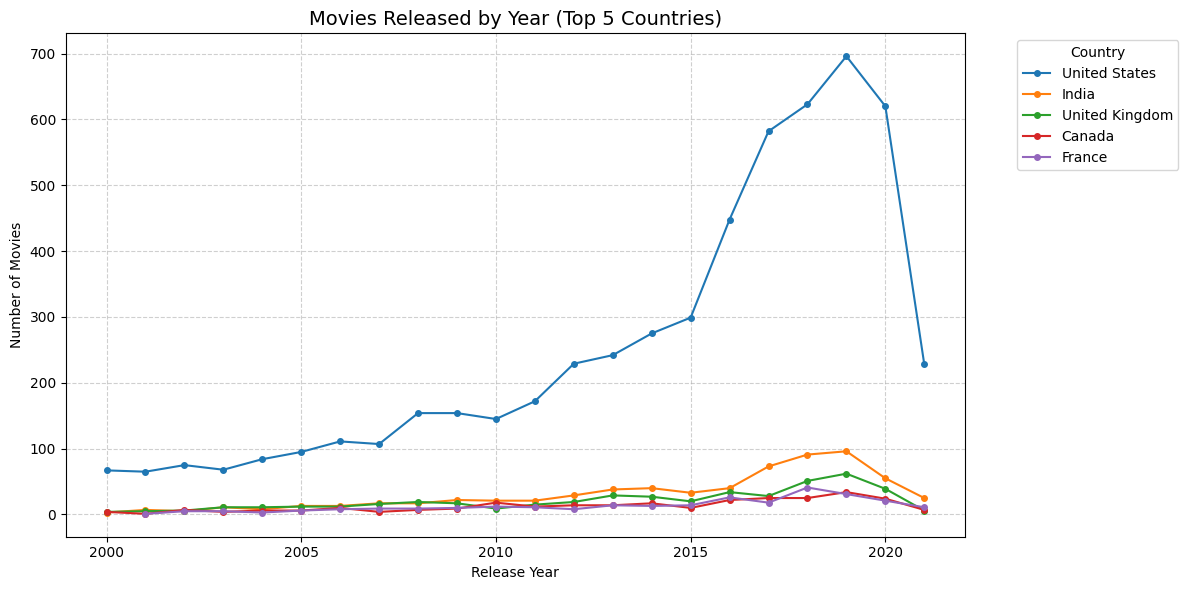

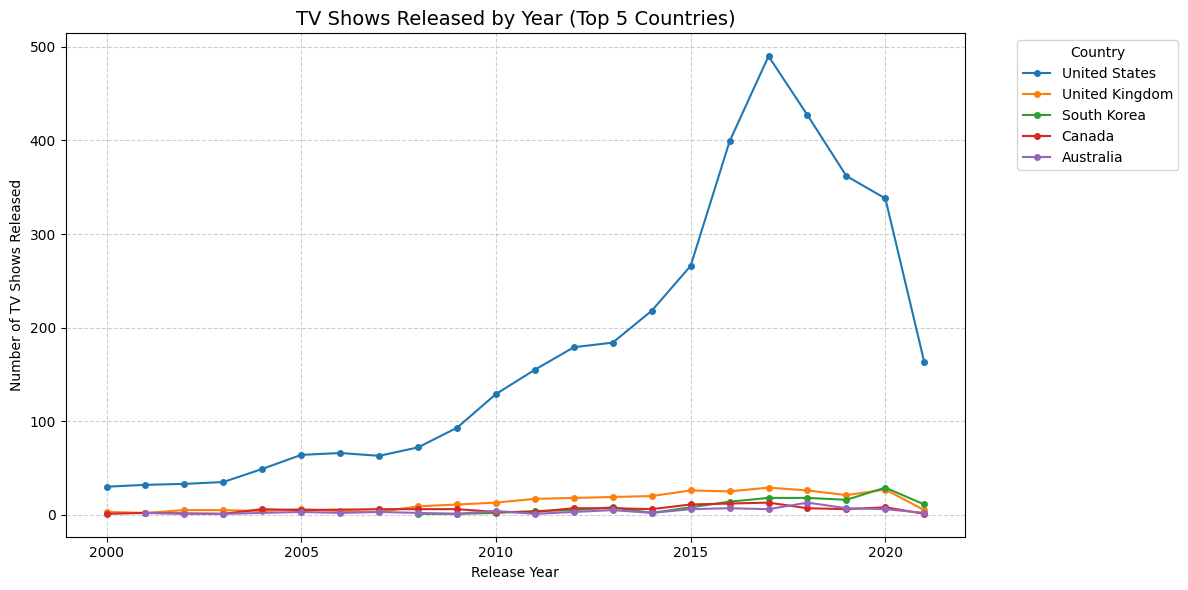

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_movies_by_country_diagnosed(movies_df, top_n=5, min_year=2000):
    print(f"Total rows in your 'movies' variable right now: {len(movies_df)}")    
    d = movies_df.copy()
    
    # Safely clean Year and Country
    d['Year'] = pd.to_numeric(d['Year'], errors="coerce")
    d = d.dropna(subset=['Year', 'Country'])

    d['Year'] = d['Year'].astype(int)
    d = d[(d['Year'] >= min_year) & (d['Year'] <= pd.Timestamp.now().year)]
    
    # Safely split and count countries
    all_countries = d['Country'].astype(str).str.split(',').explode().str.strip()
    all_countries = all_countries[all_countries != '']
    top_countries = all_countries.value_counts().head(top_n).index.tolist()
        
    # Build the plot
    plt.figure(figsize=(12, 6))
    
    for country in top_countries:
        counts = d[d['Country'].astype(str).str.contains(country, na=False, regex=False)]
        counts = counts.groupby('Year').size()
        
        if not counts.empty:
            plt.plot(counts.index, counts.values, marker='o', markersize=4, label=country)
            
    plt.title(f"Movies Released by Year (Top {top_n} Countries)", fontsize=14)
    plt.xlabel("Release Year")
    plt.ylabel("Number of Movies")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the function!
plot_movies_by_country_diagnosed(movies)


import matplotlib.pyplot as plt
from collections import defaultdict

def line_counts_by_year_country_safe(df, year_col="Year", country_col="Country", top_n=5, min_year=2000):
    d = df.copy()
    
    # 1. Clean the years
    d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    d = d.dropna(subset=[year_col, country_col])
    d[year_col] = d[year_col].astype(int)
    
    # Filter by minimum year
    d = d[(d[year_col] >= min_year) & (d[year_col] <= pd.Timestamp.now().year)]
    
    # 2. Bulletproof manual counting (bypasses .explode() completely)
    country_year_counts = defaultdict(lambda: defaultdict(int))
    total_country_counts = defaultdict(int)
    
    for _, row in d.iterrows():
        year = row[year_col]
        # Split multiple countries by comma and clean up spaces
        countries = str(row[country_col]).split(',')
        for c in countries:
            c = c.strip()
            if c: 
                country_year_counts[c][year] += 1
                total_country_counts[c] += 1
                
    # 3. Find the Top N countries based on total shows
    top_countries = sorted(total_country_counts.keys(), key=lambda x: total_country_counts[x], reverse=True)[:top_n]

    # 4. Build the plot
    plt.figure(figsize=(12, 6))
    
    for country in top_countries:
        year_data = country_year_counts[country]
        years = sorted(year_data.keys())
        counts = [year_data[y] for y in years]
        
        plt.plot(years, counts, marker='o', markersize=4, label=country)
    
    plt.title(f"TV Shows Released by Year (Top {top_n} Countries)", fontsize=14)
    plt.xlabel("Release Year")
    plt.ylabel("Number of TV Shows Released")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the bulletproof function
line_counts_by_year_country_safe(tv)

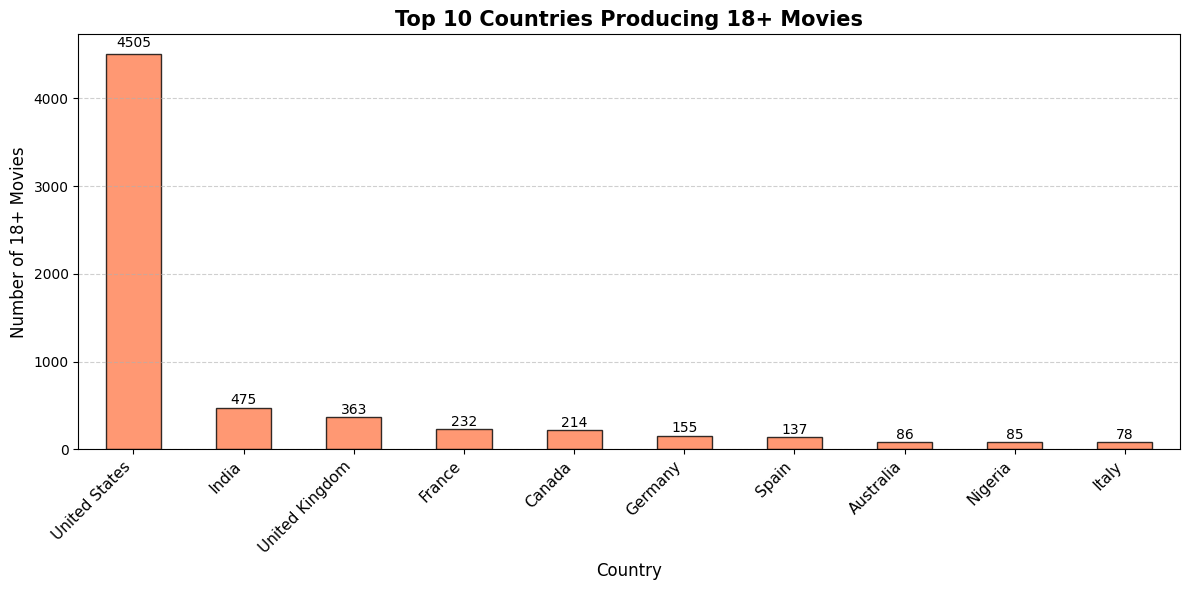

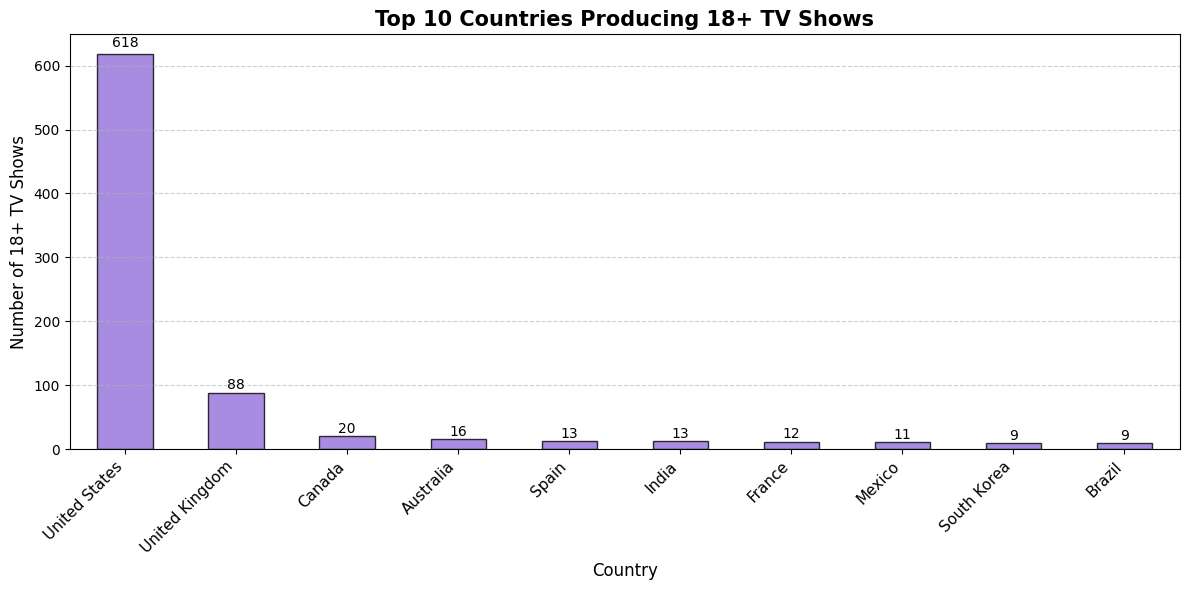

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_18plus_countries(movies_df, top_n=10):
    # 1. Make a copy of the dataframe and drop missing Age/Country rows
    d = movies_df.copy()
    d = d.dropna(subset=['Age', 'Country'])
    
    # 2. Filter for 18+ movies 
    # (We use .str.contains('18') to safely catch '18+' or '18')
    adult_movies = d[d['Age'].astype(str).str.contains('18', na=False)]
    
    
    # 3. Split comma-separated countries and count them up
    # .explode() separates rows where multiple countries collaborated on one movie
    countries = adult_movies['Country'].astype(str).str.split(',').explode().str.strip()
    countries = countries[countries != ''] # Remove any accidental blank spaces
    
    # Get the top N countries
    top_countries = countries.value_counts().head(top_n)
    
    # 4. Build the Bar Chart
    plt.figure(figsize=(12, 6))
    
    # Plotting the bar chart
    top_countries.plot(kind='bar', color='coral', edgecolor='black', alpha=0.8)
    
    plt.title(f"Top {top_n} Countries Producing 18+ Movies", fontsize=15, fontweight='bold')
    plt.xlabel("Country", fontsize=12)
    plt.ylabel("Number of 18+ Movies", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Add the exact count on top of each bar for readability
    for index, value in enumerate(top_countries):
        plt.text(index, value + (value * 0.01), str(value), ha='center', va='bottom', fontsize=10)
        
    plt.tight_layout()
    plt.show()

plot_top_18plus_countries(movies, top_n=10)


import pandas as pd
import matplotlib.pyplot as plt

def plot_top_18plus_countries_tv(tv_df, top_n=10):
    # 1. Make a copy of the dataframe and drop missing Age/Country rows
    d = tv_df.copy()
    d = d.dropna(subset=['Age', 'Country'])
    
    # 2. Filter for 18+ TV shows
    # (We use .str.contains('18') to safely catch '18+' or '18')
    adult_tv = d[d['Age'].astype(str).str.contains('18', na=False)]

    # 3. Split comma-separated countries and count them up
    countries = adult_tv['Country'].astype(str).str.split(',').explode().str.strip()
    countries = countries[countries != ''] # Remove any accidental blank spaces
    
    # Get the top N countries
    top_countries = countries.value_counts().head(top_n)
    
    # 4. Build the Bar Chart
    plt.figure(figsize=(12, 6))
    
    # Plotting the bar chart (using a different color for TV Shows)
    top_countries.plot(kind='bar', color='mediumpurple', edgecolor='black', alpha=0.8)
    
    # Formatting the chart
    plt.title(f"Top {top_n} Countries Producing 18+ TV Shows", fontsize=15, fontweight='bold')
    plt.xlabel("Country", fontsize=12)
    plt.ylabel("Number of 18+ TV Shows", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Add the exact count on top of each bar for readability
    for index, value in enumerate(top_countries):
        plt.text(index, value + (value * 0.01), str(value), ha='center', va='bottom', fontsize=10)
        
    plt.tight_layout()
    plt.show()


plot_top_18plus_countries_tv(tv, top_n=10)

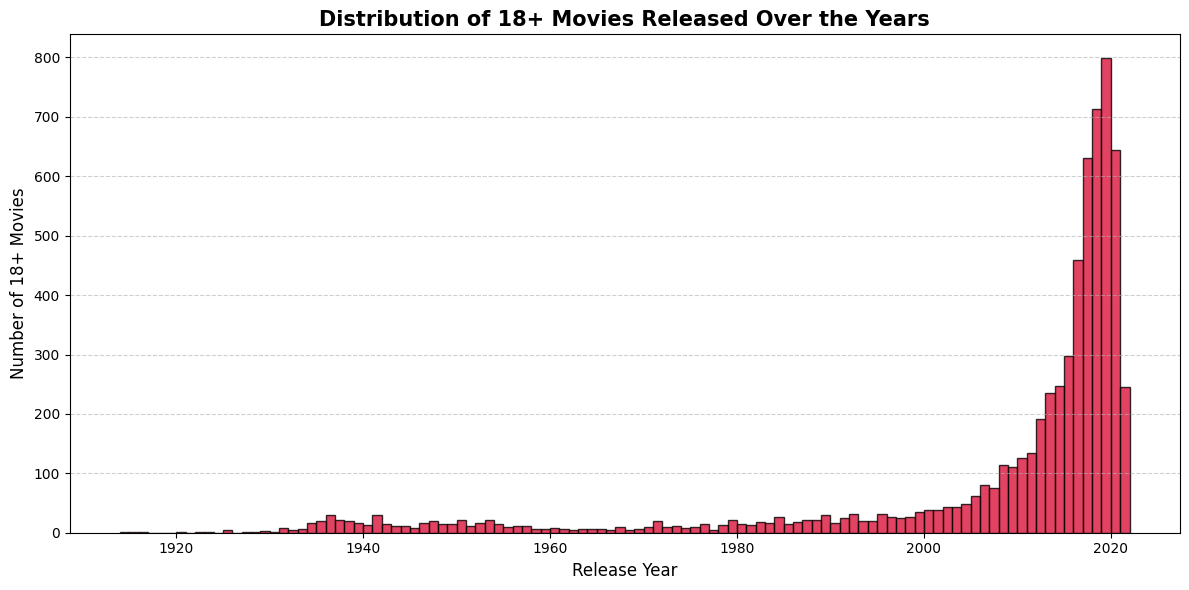

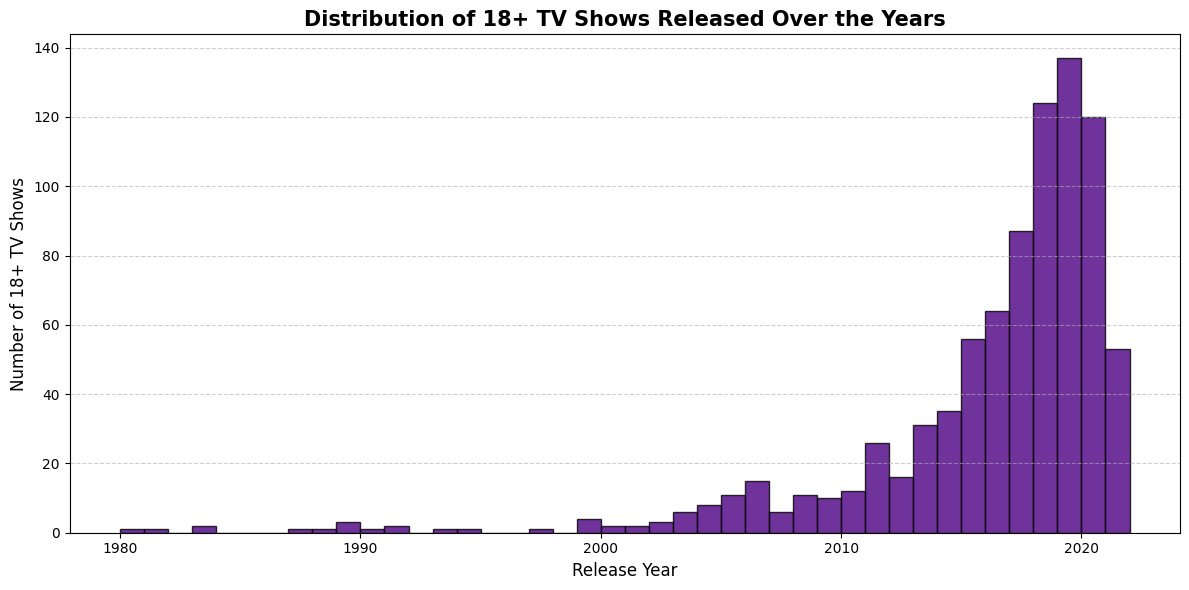

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_18plus_movies_histogram(movies_df):
    # 1. Make a copy and drop rows missing Age or Year
    d = movies_df.copy()
    d = d.dropna(subset=['Age', 'Year'])
    
    # 2. Safely clean the Year column
    d['Year'] = pd.to_numeric(d['Year'], errors='coerce')
    d = d.dropna(subset=['Year'])
    d['Year'] = d['Year'].astype(int)
    
    # 3. Filter for 18+ movies only
    adult_movies = d[d['Age'].astype(str).str.contains('18', na=False)]
    
    # 4. Build the Histogram
    plt.figure(figsize=(12, 6))
    
    # We create custom 'bins' (buckets) so every single year gets its own bar
    min_year = adult_movies['Year'].min()
    max_year = adult_movies['Year'].max()
    year_bins = range(min_year, max_year + 2) 
    
    # Plotting the histogram
    plt.hist(adult_movies['Year'], bins=year_bins, color='crimson', edgecolor='black', alpha=0.8)
    
    # Formatting the chart
    plt.title("Distribution of 18+ Movies Released Over the Years", fontsize=15, fontweight='bold')
    plt.xlabel("Release Year", fontsize=12)
    plt.ylabel("Number of 18+ Movies", fontsize=12)
    
    # Add a grid to make it easier to read the exact counts
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()


plot_18plus_movies_histogram(movies)


import pandas as pd
import matplotlib.pyplot as plt

def plot_18plus_tv_histogram(tv_df):
    # 1. Make a copy and drop rows missing Age or Year
    d = tv_df.copy()
    d = d.dropna(subset=['Age', 'Year'])
    
    # 2. Safely clean the Year column
    d['Year'] = pd.to_numeric(d['Year'], errors='coerce')
    d = d.dropna(subset=['Year'])
    d['Year'] = d['Year'].astype(int)
    
    # 3. Filter for 18+ TV shows only
    adult_tv = d[d['Age'].astype(str).str.contains('18', na=False)]
        
    # 4. Build the Histogram
    plt.figure(figsize=(12, 6))
    
    # We create custom 'bins' (buckets) so every single year gets its own bar
    min_year = adult_tv['Year'].min()
    max_year = adult_tv['Year'].max()
    year_bins = range(min_year, max_year + 2) 
    
    # Plotting the histogram (using indigo for TV shows)
    plt.hist(adult_tv['Year'], bins=year_bins, color='indigo', edgecolor='black', alpha=0.8)
    
    # Formatting the chart
    plt.title("Distribution of 18+ TV Shows Released Over the Years", fontsize=15, fontweight='bold')
    plt.xlabel("Release Year", fontsize=12)
    plt.ylabel("Number of 18+ TV Shows", fontsize=12)
    
    # Add a grid to make it easier to read the exact counts
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

plot_18plus_tv_histogram(tv)


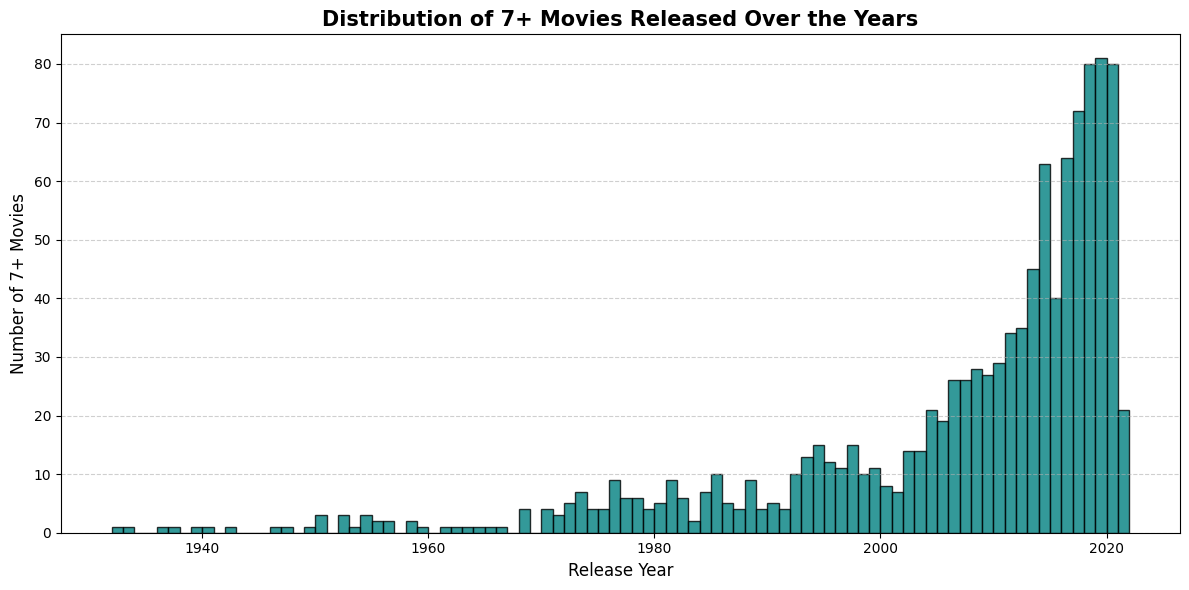

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_7plus_movies_histogram(movies_df):
    # 1. Make a copy and drop rows missing Age or Year
    d = movies_df.copy()
    d = d.dropna(subset=['Age', 'Year'])
    
    # 2. Safely clean the Year column
    d['Year'] = pd.to_numeric(d['Year'], errors='coerce')
    d = d.dropna(subset=['Year'])
    d['Year'] = d['Year'].astype(int)
    
    # 3. Filter for 7+ movies only
    # (Using .str.contains('7') safely catches '7+' or '7')
    kids_movies = d[d['Age'].astype(str).str.contains('7', na=False)]
  
    # 4. Build the Histogram
    plt.figure(figsize=(12, 6))
    
    # We create custom 'bins' (buckets) so every single year gets its own bar
    min_year = kids_movies['Year'].min()
    max_year = kids_movies['Year'].max()
    year_bins = range(min_year, max_year + 2) 
    
    # Plotting the histogram (using teal for 7+ movies)
    plt.hist(kids_movies['Year'], bins=year_bins, color='teal', edgecolor='black', alpha=0.8)
    
    # Formatting the chart
    plt.title("Distribution of 7+ Movies Released Over the Years", fontsize=15, fontweight='bold')
    plt.xlabel("Release Year", fontsize=12)
    plt.ylabel("Number of 7+ Movies", fontsize=12)
    
    # Add a grid to make it easier to read the exact counts
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

plot_7plus_movies_histogram(movies)